# Система ценообразования и оптимизатор цен

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor

## Настройка

In [2]:
# Пути
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "model_dataset.parquet"
MODEL_PATH = PROJECT_ROOT / "artifacts" / "models" / "best_model.cbm"

OUTPUT_TABLE_PATH = (
    PROJECT_ROOT / "artifacts" / "tables" / "pricing_recommendations.parquet"
)

FIGURES_DIR = (
    PROJECT_ROOT / "artifacts" / "figures" / "pricing"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)

In [3]:
# Основные колонки
TARGET_COL = "item_cnt_month"
PRICE_COL = "avg_price"

SHOP_COL = "shop_id_target_enc"
ITEM_COL = "item_id_target_enc"

# Себестоимость.
COST_COL = None

# Диапазон изменения цены
PRICE_CHANGE_MIN = -0.20
PRICE_CHANGE_MAX = 0.20

# Количество кандидатных цен
N_PRICE_CANDIDATES = 50

## Загрузка данных

In [4]:
df = pd.read_parquet(DATA_PATH)

df.head()

,date_block_num,year,month,item_cnt_month,avg_price,lag_1,lag_2,lag_3,lag_6,lag_12,...,month_sin,month_cos,is_summer,is_winter,days_in_month,shop_id_target_enc,item_id_target_enc,item_category_id_target_enc,main_category_target_enc,super_category_target_enc
0,13,2014,2,0.0,119.0,1.0,0.0,0.0,0.0,0.0,...,0.866025,0.5,0,1,28,0.170076,2.479303,0.259266,0.223939,0.223939
1,13,2014,2,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.866025,0.5,0,1,28,0.246914,0.000000,0.165687,0.223939,0.223939
2,13,2014,2,1.0,1699.0,0.0,2.0,0.0,0.0,0.0,...,0.866025,0.5,0,1,28,0.283779,0.256410,0.323786,0.291757,0.291757
3,13,2014,2,0.0,199.0,0.0,1.0,1.0,1.0,0.0,...,0.866025,0.5,0,1,28,0.544732,0.175321,0.225952,0.208121,0.208121
4,13,2014,2,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.866025,0.5,0,1,28,0.234513,0.000000,0.225952,0.208121,0.208121


## Загрузка модели

Модель не переобучается, а используется как функция Q = f(X, P)

где:

X - признаки товара, магазина и времени

P - рассматриваемая цена

Q - прогнозируемый объем спроса

In [5]:
model = CatBoostRegressor()

model.load_model(MODEL_PATH)

CatBoostRegressor(border_count=183, depth=10, iterations=600, l2_leaf_reg=0.8851428265, learning_rate=0.04465378952, loss_function='RMSE')

## Проверка признаков модели

In [6]:
model_features = model.feature_names_

print(f"Кол-во признаков: {len(model_features)}")
print(model_features)

Кол-во признаков: 30
['year', 'month', 'avg_price', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'pred_hist_avg', 'item_cnt_roll_mean_3', 'item_cnt_roll_mean_6', 'item_cnt_roll_mean_12', 'item_cnt_roll_std_3', 'item_cnt_roll_std_6', 'item_cnt_roll_max_3', 'item_cnt_roll_min_3', 'price_lag_1', 'price_lag_2', 'price_change', 'item_avg_price_roll_mean_3', 'month_sin', 'month_cos', 'is_summer', 'is_winter', 'days_in_month', 'shop_id_target_enc', 'item_id_target_enc', 'item_category_id_target_enc', 'main_category_target_enc', 'super_category_target_enc']


In [7]:
missing_features = [
    col for col in model_features
    if col not in df.columns
]

if missing_features:
    raise ValueError(
        f"Пропущенные признаки, требуемые моделью: {missing_features}"
    )

print("Все признаки присутствуют")

Все признаки присутствуют


## Определение последнего допустимого месяца

In [8]:
print(df["date_block_num"].dtype)
print(df["date_block_num"].min())
print(df["date_block_num"].max())

int64
13
33


In [9]:
last_month = df["date_block_num"].max()

forecast_month = (
    last_month + 1
)

print("Последний месяц в истории:", last_month)
print("Прогнозируемый месяц:", forecast_month)

Последний месяц в истории: 33
Прогнозируемый месяц: 34


## Пример товара

Перед применением оптимизации ко всему ассортименту, проверим алгоритм на одном товаре в одном магазине

In [10]:
last_data = df[df["date_block_num"] == last_month].copy()

example_row = (
    last_data
    .sort_values('item_cnt_roll_mean_3', ascending=False)
    .iloc[0]
)

last_month = df["date_block_num"].max()
forecast_month = last_month + 1

print("Последний месяц истории:", last_month)
print("Месяц прогнозирования:", forecast_month)

Последний месяц истории: 33
Месяц прогнозирования: 34


In [18]:
example_row[['item_id_target_enc', 'shop_id_target_enc']]

item_id_target_enc    74.220453
shop_id_target_enc     0.411292
Name: 7944546, dtype: float64

In [20]:
example_shop = 0.411292
example_item = 74.220453

In [ ]:
tol = 1e-6
mask = (
    (df["shop_id_target_enc"].round(6) == round(example_shop, 6)) &
    (df["item_id_target_enc"].round(6) == round(example_item, 6))
)
df[mask]

,date_block_num,year,month,item_cnt_month,avg_price,lag_1,lag_2,lag_3,lag_6,lag_12,...,month_sin,month_cos,is_summer,is_winter,days_in_month,shop_id_target_enc,item_id_target_enc,item_category_id_target_enc,main_category_target_enc,super_category_target_enc
7944546,33,2015,10,131.0,5.0,200.0,251.0,229.0,143.0,175.0,...,-0.866025,0.5,0,0,31,0.411292,74.220453,67.273523,0.298109,0.298109


In [27]:
def create_future_row(
    full_df: pd.DataFrame,
    shop_id,
    item_id,
    price: float | None = None,
) -> pd.Series:

    mask = (
    (full_df["shop_id_target_enc"].round(6) == round(shop_id, 6)) &
    (full_df["item_id_target_enc"].round(6) == round(item_id, 6))
)

    history = (
        full_df[mask]
        .sort_values("date_block_num")
        .copy()
    )

    if history.empty:
        raise ValueError(
            f"Нет истории для shop_id={shop_id}, item_id={item_id}"
        )

    last_row = history.iloc[-1]

    last_month = int(last_row["date_block_num"])
    future_month = last_month + 1

    future_row = last_row.copy()

    future_row["date_block_num"] = future_month

    future_row["month"] = (future_month % 12) + 1

    future_row[TARGET_COL] = np.nan

    sales = history[TARGET_COL].reset_index(drop=True)

    future_row["lag_1"] = (
        sales.iloc[-1]
        if len(sales) >= 1
        else np.nan
    )

    future_row["lag_2"] = (
        sales.iloc[-2]
        if len(sales) >= 2
        else np.nan
    )

    future_row["lag_3"] = (
        sales.iloc[-3]
        if len(sales) >= 3
        else np.nan
    )

    future_row["lag_6"] = (
        sales.iloc[-6]
        if len(sales) >= 6
        else np.nan
    )

    future_row["lag_12"] = (
        sales.iloc[-12]
        if len(sales) >= 12
        else np.nan
    )

    future_row["pred_hist_avg"] = sales.mean()


    future_row["item_cnt_roll_mean_3"] = (
        sales.tail(3).mean()
    )

    future_row["item_cnt_roll_mean_6"] = (
        sales.tail(6).mean()
    )

    future_row["item_cnt_roll_mean_12"] = (
        sales.tail(12).mean()
    )

    future_row["item_cnt_roll_std_3"] = (
        sales.tail(3).std()
    )

    future_row["item_cnt_roll_std_6"] = (
        sales.tail(6).std()
    )

    future_row["item_cnt_roll_max_3"] = (
        sales.tail(3).max()
    )

    future_row["item_cnt_roll_min_3"] = (
        sales.tail(3).min()
    )

    prices = history[PRICE_COL].reset_index(drop=True)

    last_price = prices.iloc[-1]

    if price is None:
        future_price = last_price
    else:
        future_price = float(price)

    future_row[PRICE_COL] = future_price

    future_row["price_lag_1"] = last_price

    future_row["price_lag_2"] = (
        prices.iloc[-2]
        if len(prices) >= 2
        else np.nan
    )

    if pd.notna(last_price):
        future_row["price_change"] = (
            future_price - last_price
        )
    else:
        future_row["price_change"] = np.nan

    future_row["item_avg_price_roll_mean_3"] = (
        prices.tail(3).mean()
    )


    month = int(future_row["month"])

    future_row["month_sin"] = np.sin(
        2 * np.pi * month / 12
    )

    future_row["month_cos"] = np.cos(
        2 * np.pi * month / 12
    )

    future_row["is_summer"] = (
        month in [6, 7, 8]
    )

    future_row["is_winter"] = (
        month in [1, 2, 12]
    )

    days_in_month = {
        1: 31,
        2: 28,
        3: 31,
        4: 30,
        5: 31,
        6: 30,
        7: 31,
        8: 31,
        9: 30,
        10: 31,
        11: 30,
        12: 31
    }

    future_row["days_in_month"] = (
        days_in_month[month]
    )

    return future_row

## Генерация кандидатов цен

In [28]:
future_row = create_future_row(
    full_df=df,
    shop_id=example_shop,
    item_id=example_item
)

C:\Users\User\AppData\Local\Temp\ipykernel_21304\544391594.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  future_row["is_summer"] = (


In [29]:
current_price = float(example_row[PRICE_COL])

min_price = current_price * (1 + PRICE_CHANGE_MIN)
max_price = current_price * (1 + PRICE_CHANGE_MAX)

candidate_prices = np.linspace(
    min_price,
    max_price,
    N_PRICE_CANDIDATES
)

candidate_prices

array([4.        , 4.04081633, 4.08163265, 4.12244898, 4.16326531,
       4.20408163, 4.24489796, 4.28571429, 4.32653061, 4.36734694,
       4.40816327, 4.44897959, 4.48979592, 4.53061224, 4.57142857,
       4.6122449 , 4.65306122, 4.69387755, 4.73469388, 4.7755102 ,
       4.81632653, 4.85714286, 4.89795918, 4.93877551, 4.97959184,
       5.02040816, 5.06122449, 5.10204082, 5.14285714, 5.18367347,
       5.2244898 , 5.26530612, 5.30612245, 5.34693878, 5.3877551 ,
       5.42857143, 5.46938776, 5.51020408, 5.55102041, 5.59183673,
       5.63265306, 5.67346939, 5.71428571, 5.75510204, 5.79591837,
       5.83673469, 5.87755102, 5.91836735, 5.95918367, 6.        ])

## Прогнозирование спроса для каждой цены

In [30]:
def predict_demand_for_price(
    model,
    base_row: pd.Series,
    candidate_price: float,
    model_features: list[str]
) -> float:

    row = create_future_row(df, base_row['shop_id_target_enc'], 
                            base_row['item_id_target_enc'],
                            candidate_price)

    X = pd.DataFrame([row])

    X = X[model_features]

    prediction = model.predict(X)[0]

    # Для количества продаж отрицательный прогноз не имеет смысла.
    prediction = max(0.0, prediction)

    return float(prediction)

In [31]:
import time

start_time = time.time()

pricing_results = []

for candidate_price in candidate_prices:

    candidate_row = future_row.copy()

    candidate_row["avg_price"] = candidate_price

    candidate_row["price_change"] = (
        candidate_price
        - candidate_row["price_lag_1"]
    )

    X_candidate = (
        candidate_row[model_features]
        .to_frame()
        .T
    )

    predicted_demand = model.predict(X_candidate)[0]
    
    pricing_results.append({
        "shop_id": example_shop,
        "item_id": example_item,
        "price": candidate_price,
        "predicted_demand": predicted_demand
    })

pricing_results = pd.DataFrame(pricing_results)

stop_time = time.time()
print(f"Время на выполнение: {round(stop_time - start_time, 3)} секунд")

pricing_results.head()

Время на выполнение: 0.055 секунд


,shop_id,item_id,price,predicted_demand
0,0.411292,74.220453,4.000000,75.878659
1,0.411292,74.220453,4.040816,75.878659
2,0.411292,74.220453,4.081633,75.796108
3,0.411292,74.220453,4.122449,75.796108
4,0.411292,74.220453,4.163265,75.796108


In [32]:
pricing_results.tail()

,shop_id,item_id,price,predicted_demand
45,0.411292,74.220453,5.836735,63.694772
46,0.411292,74.220453,5.877551,63.694772
47,0.411292,74.220453,5.918367,63.694772
48,0.411292,74.220453,5.959184,63.694772
49,0.411292,74.220453,6.000000,63.694772


## Подсчет прибыли

Для каждой кандидатной цены рассчитывается ожидаемая выручка:

Revenue(P) = P / Q(P)

где:

P - кандидатная цена

Q(P) - прогнозируемые спрос при данной цене

In [33]:
pricing_results["expected_revenue"] = (
    pricing_results["price"]
    * pricing_results["predicted_demand"]
)

pricing_results.head()

,shop_id,item_id,price,predicted_demand,expected_revenue
0,0.411292,74.220453,4.000000,75.878659,303.514635
1,0.411292,74.220453,4.040816,75.878659,306.611723
2,0.411292,74.220453,4.081633,75.796108,309.371868
3,0.411292,74.220453,4.122449,75.796108,312.465587
4,0.411292,74.220453,4.163265,75.796108,315.559306


## Оптимальная цена

In [34]:
optimal_idx = pricing_results["expected_revenue"].idxmax()

optimal_row = pricing_results.loc[optimal_idx]

optimal_price = optimal_row["price"]
optimal_demand = optimal_row["predicted_demand"]
optimal_revenue = optimal_row["expected_revenue"]

print(f"Текущая цена:     {current_price:.2f}")
print(f"Оптимальная цена:     {optimal_price:.2f}")
print(f"Ожидаемый спрос:   {optimal_demand:.2f}")
print(f"Ожидаемый доход:  {optimal_revenue:.2f}")

Текущая цена:     5.00
Оптимальная цена:     4.98
Ожидаемый спрос:   84.89
Ожидаемый доход:  422.70


## Сравнение цен

In [35]:
current_prediction = pricing_results.iloc[
    (pricing_results["price"] - current_price)
    .abs()
    .argsort()[:1]
].iloc[0]

current_demand = current_prediction["predicted_demand"]
current_revenue = current_prediction["expected_revenue"]

comparison = pd.DataFrame({
    "Метрики": [
        "Цена",
        "Спрогнозируемый спрос",
        "Ожидаемый доход"
    ],
    "Текущие": [
        current_price,
        current_demand,
        current_revenue
    ],
    "Оптимальные": [
        optimal_price,
        optimal_demand,
        optimal_revenue
    ]
})

comparison

,Метрики,Текущие,Оптимальные
0,Цена,5.000000,4.979592
1,Спрогнозируемый спрос,84.885835,84.885835
2,Ожидаемый доход,422.696810,422.696810


## Графики

### Зависимость прогнозируемого спроса от цены

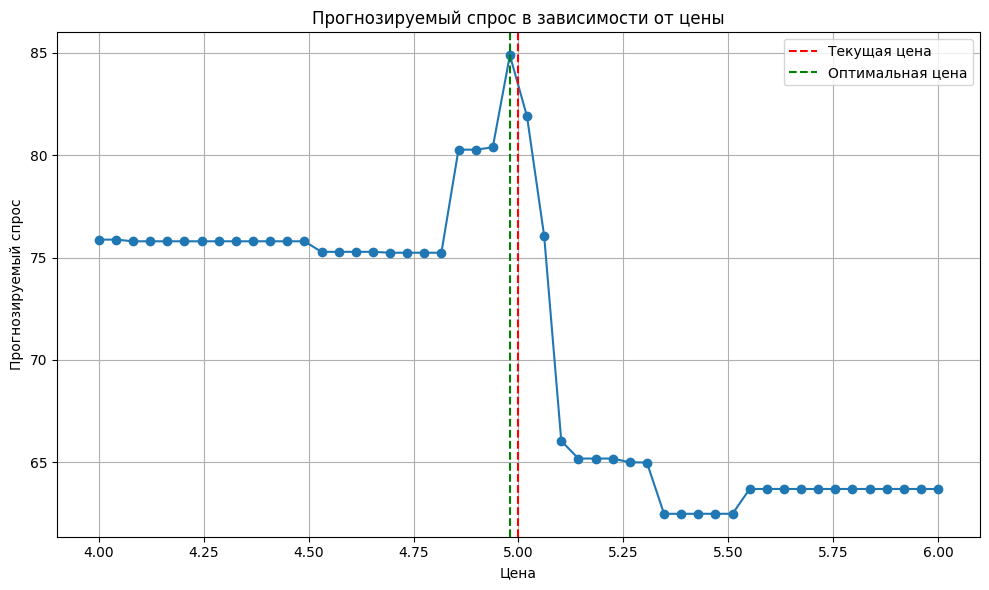

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    pricing_results["price"],
    pricing_results["predicted_demand"],
    marker="o"
)

plt.axvline(
    current_price,
    linestyle="--",
    label="Текущая цена",
    color = 'red'
)

plt.axvline(
    optimal_price,
    linestyle="--",
    label="Оптимальная цена",
    color = 'green'
)

plt.xlabel("Цена")
plt.ylabel("Прогнозируемый спрос")
plt.title("Прогнозируемый спрос в зависимости от цены")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "demand_price_curve.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Зависимость ожидаемой выручки от цены

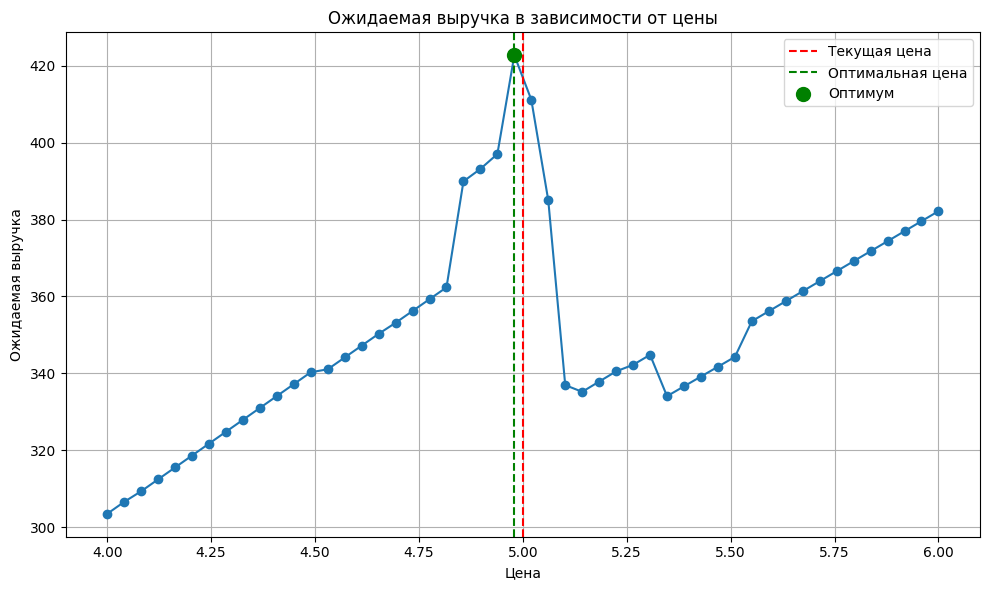

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    pricing_results["price"],
    pricing_results["expected_revenue"],
    marker="o"
)

plt.axvline(
    current_price,
    linestyle="--",
    label="Текущая цена",
    color = "red"
)

plt.axvline(
    optimal_price,
    linestyle="--",
    label="Оптимальная цена",
    color = 'green'
)

plt.scatter(
    [optimal_price],
    [optimal_revenue],
    s=100,
    zorder=5,
    label="Оптимум",
    color = 'green'
)

plt.xlabel("Цена")
plt.ylabel("Ожидаемая выручка")
plt.title("Ожидаемая выручка в зависимости от цены")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "revenue_price_curve.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Таблица

In [38]:
pricing_results.round(3)

,shop_id,item_id,price,predicted_demand,expected_revenue
0,0.411,74.22,4.000,75.879,303.515
1,0.411,74.22,4.041,75.879,306.612
2,0.411,74.22,4.082,75.796,309.372
3,0.411,74.22,4.122,75.796,312.466
4,0.411,74.22,4.163,75.796,315.559
5,0.411,74.22,4.204,75.796,318.653
6,0.411,74.22,4.245,75.796,321.747
7,0.411,74.22,4.286,75.796,324.840
8,0.411,74.22,4.327,75.796,327.934
9,0.411,74.22,4.367,75.796,331.028


## Универсальная функция оптимизации

In [39]:
def optimize_price(
    model,
    row: pd.Series,
    model_features: list[str],
    price_col: str = PRICE_COL,
    min_change: float = -0.10,
    max_change: float = 0.10,
    n_candidates: int = 21,
    cost: float | None = None
) -> dict:
    """
    Оптимизация цены для одного объекта shop × item.
    """
    
    current_price = float(row[price_col])
    
    min_price = current_price * (1 + min_change)
    max_price = current_price * (1 + max_change)
    
    prices = np.linspace(
        min_price,
        max_price,
        n_candidates
    )
    
    candidates = []
    
    for price in prices:
        
        predicted_demand = predict_demand_for_price(
            model=model,
            base_row=row,
            candidate_price=price,
            model_features=model_features
        )
        
        revenue = price * predicted_demand
        
        result = {
            SHOP_COL: row[SHOP_COL],
            ITEM_COL: row[ITEM_COL],
            "current_price": current_price,
            "candidate_price": price,
            "predicted_demand": predicted_demand,
            "expected_revenue": revenue
        }
        
        if cost is not None:
            result["expected_profit"] = (
                (price - cost) * predicted_demand
            )
        
        candidates.append(result)
    
    candidates = pd.DataFrame(candidates)
    
    # Если себестоимость доступна — максимизируем прибыль.
    # Иначе — выручку.
    if cost is not None:
        best_idx = candidates["expected_profit"].idxmax()
    else:
        best_idx = candidates["expected_revenue"].idxmax()
    
    best = candidates.loc[best_idx]
    
    return {
        SHOP_COL: best[SHOP_COL],
        ITEM_COL: best[ITEM_COL],
        "current_price": best["current_price"],
        "optimal_price": best["candidate_price"],
        "predicted_demand": best["predicted_demand"],
        "expected_revenue": best["expected_revenue"],
        "expected_profit": (
            best["expected_profit"]
            if cost is not None
            else np.nan
        )
    }

In [40]:
recommendation = optimize_price(
    model=model,
    row=example_row,
    model_features=model_features,
    min_change=PRICE_CHANGE_MIN,
    max_change=PRICE_CHANGE_MAX,
    n_candidates=N_PRICE_CANDIDATES
)

recommendation

C:\Users\User\AppData\Local\Temp\ipykernel_21304\544391594.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  future_row["is_summer"] = (
C:\Users\User\AppData\Local\Temp\ipykernel_21304\544391594.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  future_row["is_summer"] = (
C:\Users\User\AppData\Local\Temp\ipykernel_21304\544391594.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  future_row["is_summer"] = (
C:\Users\User\AppData\Local\Temp\i

{'shop_id_target_enc': np.float64(0.4112916473407545),
 'item_id_target_enc': np.float64(74.2204529824825),
 'current_price': np.float64(5.0),
 'optimal_price': np.float64(4.979591836734694),
 'predicted_demand': np.float64(84.88583478153242),
 'expected_revenue': np.float64(422.6968099325288),
 'expected_profit': nan}

## Прогон по всему ассортименту

In [41]:
def optimize_prices_batch(
    model,
    data: pd.DataFrame,
    model_features: list[str],
    price_col: str = PRICE_COL,
    min_change: float = -0.10,
    max_change: float = 0.10,
    n_candidates: int = 21
) -> pd.DataFrame:
    
    results = []
    
    for _, row in data.iterrows():
        
        recommendation = optimize_price(
            model=model,
            row=row,
            model_features=model_features,
            price_col=price_col,
            min_change=min_change,
            max_change=max_change,
            n_candidates=n_candidates
        )
        
        results.append(recommendation)
    
    return pd.DataFrame(results)

In [42]:
sample_data = (
    last_data
    .head(100)
    .copy()
)

recommendations_sample = optimize_prices_batch(
    model=model,
    data=sample_data,
    model_features=model_features,
    min_change=PRICE_CHANGE_MIN,
    max_change=PRICE_CHANGE_MAX,
    n_candidates=N_PRICE_CANDIDATES
)

recommendations_sample.head()

C:\Users\User\AppData\Local\Temp\ipykernel_21304\544391594.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  future_row["is_summer"] = (
C:\Users\User\AppData\Local\Temp\ipykernel_21304\544391594.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  future_row["is_summer"] = (
C:\Users\User\AppData\Local\Temp\ipykernel_21304\544391594.py:141: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  future_row["is_summer"] = (
C:\Users\User\AppData\Local\Temp\i

,shop_id_target_enc,item_id_target_enc,current_price,optimal_price,predicted_demand,expected_revenue,expected_profit
0,0.165653,0.093299,2599.0,3118.800000,1.782357,5558.813973,NaN
1,0.246109,0.045100,349.0,393.159184,1.885581,741.333455,NaN
2,0.208184,0.058712,28.0,33.600000,0.794932,26.709716,NaN
3,0.246109,0.057816,248.0,297.600000,1.320177,392.884632,NaN
4,0.246109,0.119889,149.0,178.800000,1.522885,272.291804,NaN


In [43]:
recommendations_sample.describe()

,shop_id_target_enc,item_id_target_enc,current_price,optimal_price,predicted_demand,expected_revenue,expected_profit
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,0.0
mean,0.208327,0.223307,538.244357,577.934999,1.822410,1092.091788,NaN
std,0.040139,0.237939,511.084039,534.848369,0.553795,1052.052239,NaN
min,0.165653,0.034343,28.000000,33.600000,0.794932,26.709716,NaN
25%,0.182135,0.076286,248.750000,297.734694,1.365536,453.869978,NaN
50%,0.195901,0.151997,399.000000,397.371429,1.759265,818.685201,NaN
75%,0.219254,0.245300,599.000000,694.351020,2.120844,1317.161591,NaN
max,0.357454,1.388498,3500.000000,3485.714286,3.868577,6383.418679,NaN


## Анализ рекомендаций

In [44]:
recommendations_sample["price_change_pct"] = (
    recommendations_sample["optimal_price"]
    / recommendations_sample["current_price"]
    - 1
) * 100

recommendations_sample[
    [
        SHOP_COL,
        ITEM_COL,
        "current_price",
        "optimal_price",
        "price_change_pct",
        "predicted_demand",
        "expected_revenue"
    ]
].head(20)

,shop_id_target_enc,item_id_target_enc,current_price,optimal_price,price_change_pct,predicted_demand,expected_revenue
0,0.165653,0.093299,2599.00,3118.800000,20.000000,1.782357,5558.813973
1,0.246109,0.045100,349.00,393.159184,12.653061,1.885581,741.333455
2,0.208184,0.058712,28.00,33.600000,20.000000,0.794932,26.709716
3,0.246109,0.057816,248.00,297.600000,20.000000,1.320177,392.884632
4,0.246109,0.119889,149.00,178.800000,20.000000,1.522885,272.291804
5,0.246109,0.093781,199.00,238.800000,20.000000,1.699746,405.899343
6,0.208184,0.047453,28.00,33.600000,20.000000,0.993813,33.392111
7,0.195832,0.855901,299.00,297.779592,-0.408163,2.001675,596.057990
8,0.246109,0.108511,291.15,349.380000,20.000000,1.676538,585.748896
9,0.246109,0.083186,399.00,397.371429,-0.408163,1.954176,776.533851


In [45]:
recommendations_sample["price_change_pct"].describe()

count    100.000000
mean      10.636735
std        9.897403
min       -1.224490
25%       -0.408163
50%       15.918367
75%       20.000000
max       20.000000
Name: price_change_pct, dtype: float64

In [46]:
recommendations_sample.to_parquet(
    OUTPUT_TABLE_PATH,
    index=False
)

print(
    f"Сохранено в: {OUTPUT_TABLE_PATH}"
)

Сохранено в: ..\artifacts\tables\pricing_recommendations.parquet


## Финальная таблица

In [47]:
final_columns = [
    SHOP_COL,
    ITEM_COL,
    "current_price",
    "optimal_price",
    "price_change_pct",
    "predicted_demand",
    "expected_revenue"
]

recommendations_sample[final_columns].head(20)

,shop_id_target_enc,item_id_target_enc,current_price,optimal_price,price_change_pct,predicted_demand,expected_revenue
0,0.165653,0.093299,2599.00,3118.800000,20.000000,1.782357,5558.813973
1,0.246109,0.045100,349.00,393.159184,12.653061,1.885581,741.333455
2,0.208184,0.058712,28.00,33.600000,20.000000,0.794932,26.709716
3,0.246109,0.057816,248.00,297.600000,20.000000,1.320177,392.884632
4,0.246109,0.119889,149.00,178.800000,20.000000,1.522885,272.291804
5,0.246109,0.093781,199.00,238.800000,20.000000,1.699746,405.899343
6,0.208184,0.047453,28.00,33.600000,20.000000,0.993813,33.392111
7,0.195832,0.855901,299.00,297.779592,-0.408163,2.001675,596.057990
8,0.246109,0.108511,291.15,349.380000,20.000000,1.676538,585.748896
9,0.246109,0.083186,399.00,397.371429,-0.408163,1.954176,776.533851
